--- MODELO DE REGRESIÓN CALCULADO ---
Coeficientes del modelo:
[ 6.16783728e+01  3.81637655e-02  1.17103100e-01 -2.37730745e-01
 -2.11284025e+00]

--- MENÚ ---
1. Predicción manual
2. Estadísticas descriptivas y gráficas
3. Salir

--- INGRESO DE DATOS PARA NUEVO CORREDOR ---

Tiempo estimado para 5 km: 31 minutos y 46 segundos

--- MENÚ ---
1. Predicción manual
2. Estadísticas descriptivas y gráficas
3. Salir

--- ESTADÍSTICAS DESCRIPTIVAS ---
Edad: media=40.45, min=10.00, max=80.00
Peso: media=68.63, min=39.20, max=96.20
Estatura: media=169.51, min=139.00, max=190.00
Tiempo: media=30.10, min=15.00, max=60.31


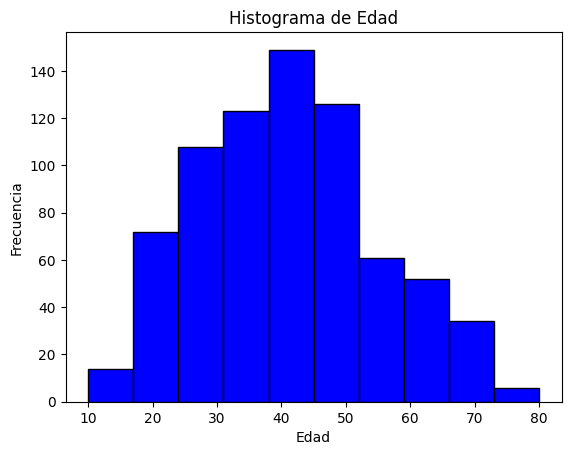

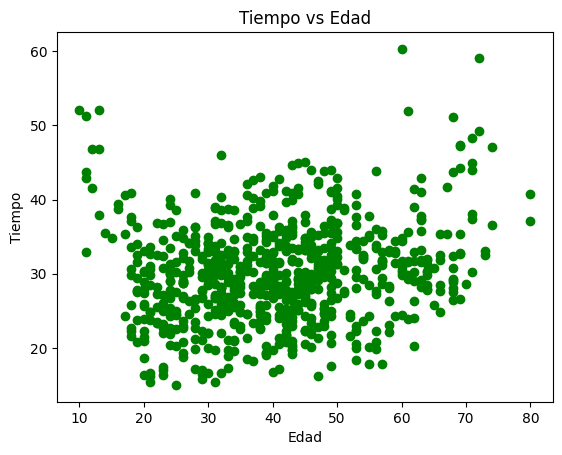

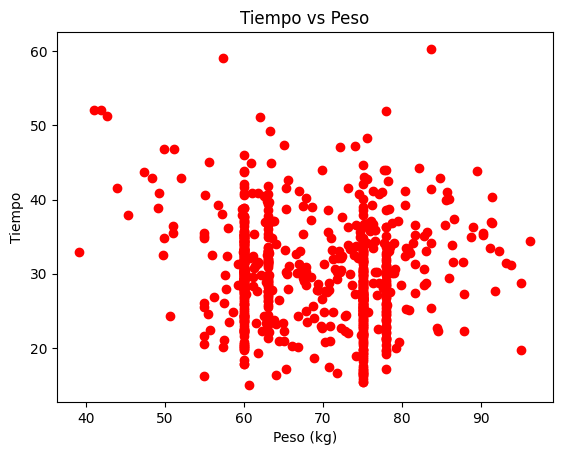

C:\Users\ARIEL\AppData\Local\Temp\ipykernel_15892\2374605406.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y[data.iloc[:, 3] == 0], y[data.iloc[:, 3] == 1]], labels=['Mujeres', 'Hombres'])


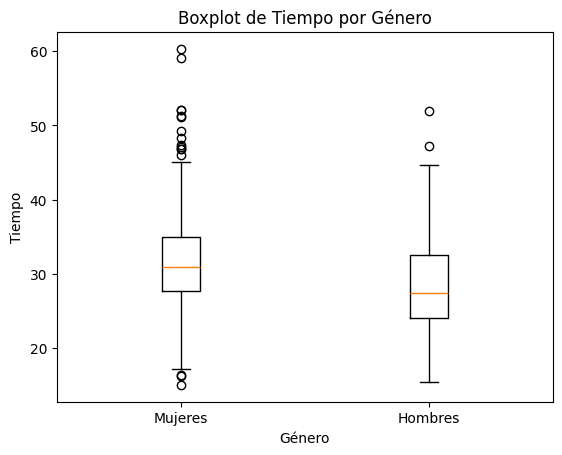


--- MENÚ ---
1. Predicción manual
2. Estadísticas descriptivas y gráficas
3. Salir

Gracias por utilizar el programa. Saliendo...


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Leer datos desde el archivo Excel
data = pd.read_csv('datasetrunningsimple_sexbin.csv')

# Variables independientes (Edad, Peso, Estatura, Género)
X = data.iloc[:, :4].values

# Variable dependiente (Tiempo)
y = data.iloc[:, 4].values

# Añadir columna de unos para el término independiente
X = np.hstack([np.ones((X.shape[0], 1)), X])

# Cálculo de β por mínimos cuadrados (X^T * X)^(-1) * X^T * y
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)

print('--- MODELO DE REGRESIÓN CALCULADO ---')
print('Coeficientes del modelo:')
print(beta)

# Inicia menú interactivo
while True:
    print('\n--- MENÚ ---')
    print('1. Predicción manual')
    print('2. Estadísticas descriptivas y gráficas')
    print('3. Salir')
    opcion = int(input('Seleccione una opción: '))

    if opcion == 1:
        # Solicita datos de un nuevo corredor y calcula el tiempo estimado
        print('\n--- INGRESO DE DATOS PARA NUEVO CORREDOR ---')
        edad = float(input('Edad: '))
        peso = float(input('Peso (kg): '))
        estatura = float(input('Estatura (cm): '))
        genero = int(input('Género (1=Hombre, 0=Mujer): '))

        nuevo = np.array([1, edad, peso, estatura, genero])  # Vector con las características del corredor
        tiempo_predicho = nuevo @ beta  # Predicción usando el modelo

        # Convierte tiempo decimal a minutos y segundos
        minutos = int(np.floor(tiempo_predicho))
        segundos = round((tiempo_predicho - minutos) * 60)

        print(f'\nTiempo estimado para 5 km: {minutos} minutos y {segundos} segundos')

    elif opcion == 2:
        # Calcula y muestra estadísticas descriptivas
        print('\n--- ESTADÍSTICAS DESCRIPTIVAS ---')
        print(f'Edad: media={np.mean(data.iloc[:, 0]):.2f}, min={np.min(data.iloc[:, 0]):.2f}, max={np.max(data.iloc[:, 0]):.2f}')
        print(f'Peso: media={np.mean(data.iloc[:, 1]):.2f}, min={np.min(data.iloc[:, 1]):.2f}, max={np.max(data.iloc[:, 1]):.2f}')
        print(f'Estatura: media={np.mean(data.iloc[:, 2]):.2f}, min={np.min(data.iloc[:, 2]):.2f}, max={np.max(data.iloc[:, 2]):.2f}')
        print(f'Tiempo: media={np.mean(y):.2f}, min={np.min(y):.2f}, max={np.max(y):.2f}')

        # Histograma de las edades de los corredores
        plt.figure()
        plt.hist(data.iloc[:, 0], bins=10, color='blue', edgecolor='black')
        plt.title('Histograma de Edad')
        plt.xlabel('Edad')
        plt.ylabel('Frecuencia')
        plt.show()

        # Diagrama de dispersión: Tiempo vs Edad
        plt.figure()
        plt.scatter(data.iloc[:, 0], y, color='green')
        plt.title('Tiempo vs Edad')
        plt.xlabel('Edad')
        plt.ylabel('Tiempo')
        plt.show()

        # Diagrama de dispersión: Tiempo vs Peso
        plt.figure()
        plt.scatter(data.iloc[:, 1], y, color='red')
        plt.title('Tiempo vs Peso')
        plt.xlabel('Peso (kg)')
        plt.ylabel('Tiempo')
        plt.show()

        # Boxplot: Tiempo por Género
        plt.figure()
        plt.boxplot([y[data.iloc[:, 3] == 0], y[data.iloc[:, 3] == 1]], labels=['Mujeres', 'Hombres'])
        plt.title('Boxplot de Tiempo por Género')
        plt.xlabel('Género')
        plt.ylabel('Tiempo')
        plt.show()

    elif opcion == 3:
        # Cierra el programa
        print('\nGracias por utilizar el programa. Saliendo...')
        break

    else:
        print('\nOpción no válida. Intente de nuevo.')
